In [222]:
import warnings

In [223]:
warnings.filterwarnings("ignore")

In [224]:
import pandas as pd

In [225]:
import numpy as np

In [226]:
from sklearn.model_selection import train_test_split

In [227]:
from sklearn.preprocessing import StandardScaler

In [228]:
from sklearn.impute import SimpleImputer

In [229]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [230]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [231]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [232]:
X_pima = pima_df[pima_cols[:-1]].copy()

In [233]:
y_pima = pima_df['Outcome']

In [234]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [235]:
X_pima[cols_to_impute] = X_pima[cols_to_impute].replace(0, np.nan)

In [236]:
imputer = SimpleImputer(strategy='median')

In [237]:
X_imputed = imputer.fit_transform(X_pima)

In [238]:
scaler = StandardScaler()

In [239]:
X_pima_scaled = scaler.fit_transform(X_imputed)

In [240]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima_scaled, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [241]:
print("Preprocessed Pima dataset shapes:")
print(f"Training set features: {X_train_p.shape} | Test set features: {X_test_p.shape}")

Preprocessed Pima dataset shapes:
Training set features: (614, 8) | Test set features: (154, 8)


Task-1.2

In [242]:
import tensorflow as tf

In [243]:
from tensorflow.keras.models import Sequential

In [244]:
from tensorflow.keras.layers import Dense

In [245]:
ann_pima = Sequential([
    Dense(16, activation='relu', input_shape=(8,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [246]:
print("Sequential ANN Architecture established:")

Sequential ANN Architecture established:


In [247]:
ann_pima.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

Task-1.3

In [248]:
ann_pima.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [249]:
print("Neural network model compiled successfully.")

Neural network model compiled successfully.


Task-1.4

In [250]:
history_pima = ann_pima.fit(
    X_train_p,
    y_train_p,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
print("\nModel training complete.")

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5051 - loss: 0.7558 - val_accuracy: 0.5285 - val_loss: 0.7493
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6253 - loss: 0.6881 - val_accuracy: 0.6016 - val_loss: 0.6779
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6701 - loss: 0.6378 - val_accuracy: 0.6341 - val_loss: 0.6252
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6884 - loss: 0.5978 - val_accuracy: 0.6504 - val_loss: 0.5833
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6965 - loss: 0.5645 - val_accuracy: 0.6504 - val_loss: 0.5518
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7047 - loss: 0.5391 - val_accuracy: 0.7073 - val_loss: 0.5244
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7149 - loss: 0.5186 - val_accuracy: 0.7236 - val_loss: 0.5040
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7210 - loss: 0.5031 - val_accuracy: 0.7236 - val_loss

Task-1.5

In [251]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [252]:
import seaborn as sns

In [253]:
import matplotlib.pyplot as plt

In [254]:
y_pred_probs = ann_pima.predict(X_test_p)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [255]:
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

In [256]:
test_acc = accuracy_score(y_test_p, y_pred_classes)

In [257]:
print(f"ANN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test_p, y_pred_classes, target_names=['No Diabetes', 'Diabetes']))

ANN Holdout Test Accuracy: 72.73%

--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.78      0.81      0.79       100
    Diabetes       0.62      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



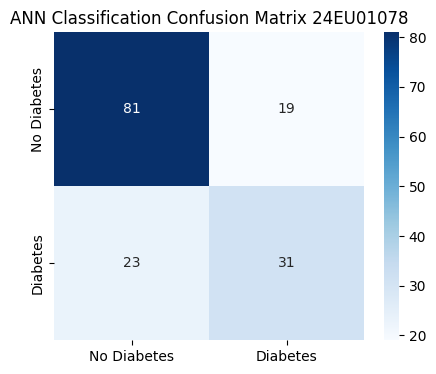

In [258]:
cm_pima = confusion_matrix(y_test_p, y_pred_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("ANN Classification Confusion Matrix 24EU01078")
plt.show()


Task-2

In [259]:
import warnings

In [260]:
warnings.filterwarnings("ignore")

In [261]:
import pandas as pd

In [262]:
from sklearn.model_selection import train_test_split

In [263]:
from sklearn.preprocessing import StandardScaler

In [264]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [265]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [266]:
sonar_columns = sonar_features + ['Class']

In [267]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [268]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [269]:
X_sonar = sonar_df[sonar_features]

In [270]:
y_sonar = sonar_df['Class_numeric']

In [271]:
scaler_sonar = StandardScaler()

In [272]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [273]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [274]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [275]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


Task-2.2

In [276]:
from tensorflow.keras.models import Sequential

In [277]:
from tensorflow.keras.layers import Dense, Dropout

In [278]:
ann_sonar = Sequential([
    Dense(64, activation='relu', input_shape=(60,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [279]:
print("Regularized Sonar ANN Architecture established:")
ann_sonar.summary()

Regularized Sonar ANN Architecture established:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

Task-2.3

In [280]:
ann_sonar.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [281]:
history_sonar = ann_sonar.fit(
    X_train_s,
    y_train_s,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
print("\nModel training complete.")

Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5086 - loss: 0.8437 - val_accuracy: 0.6207 - val_loss: 0.7136
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5862 - loss: 0.7074 - val_accuracy: 0.6207 - val_loss: 0.6508
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5862 - loss: 0.6784 - val_accuracy: 0.6552 - val_loss: 0.6092
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6810 - loss: 0.5791 - val_accuracy: 0.7241 - val_loss: 0.5707
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7069 - loss: 0.5398 - val_accuracy: 0.7241 - val_loss: 0.5539
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6638 - loss: 0.6155 - val_accuracy: 0.7586 - val_loss: 0.5357
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7586 - loss: 0.5353 - val_accuracy: 0.7586 - val_loss: 0.5221
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7672 - loss: 0.4924 - val_accuracy: 0.7931 - val_loss: 0.5026


Task-2.4

In [282]:
import matplotlib.pyplot as plt

In [283]:
train_loss = history_sonar.history['loss']
val_loss = history_sonar.history['val_loss']
train_acc = history_sonar.history['accuracy']
val_acc = history_sonar.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

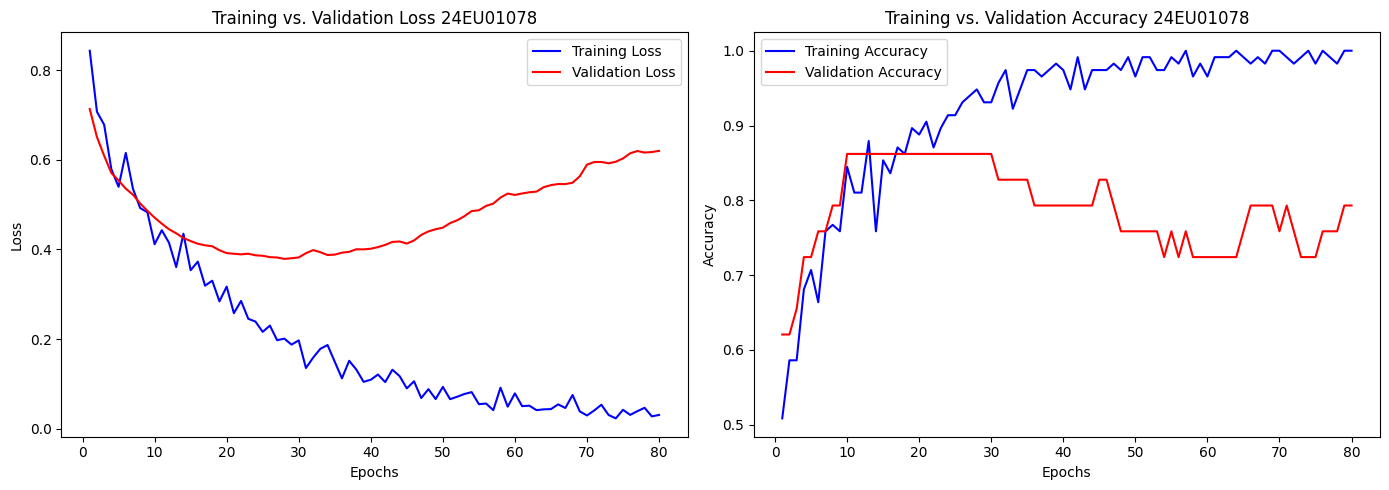

In [284]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs_range, val_loss, 'r-', label='Validation Loss')
axes[0].set_title("Training vs. Validation Loss 24EU01078")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(epochs_range, train_acc, 'b-', label='Training Accuracy')
axes[1].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
axes[1].set_title("Training vs. Validation Accuracy 24EU01078")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

Task-2.5

In [285]:
from sklearn.metrics import classification_report, roc_curve, auc

In [286]:
import matplotlib.pyplot as plt

In [287]:
sonar_probs = ann_sonar.predict(X_test_s)[:, 0]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [288]:
sonar_preds = (sonar_probs >= 0.5).astype(int)

In [289]:
print("--- Classification Report (Sonar Test Set) ---")
print(classification_report(y_test_s, sonar_preds, target_names=['Rock (0)', 'Mine (1)']))

--- Classification Report (Sonar Test Set) ---
              precision    recall  f1-score   support

    Rock (0)       0.81      0.86      0.83        29
    Mine (1)       0.88      0.82      0.85        34

    accuracy                           0.84        63
   macro avg       0.84      0.84      0.84        63
weighted avg       0.84      0.84      0.84        63



In [290]:
fpr, tpr, _ = roc_curve(y_test_s, sonar_probs)

In [291]:
roc_auc = auc(fpr, tpr)

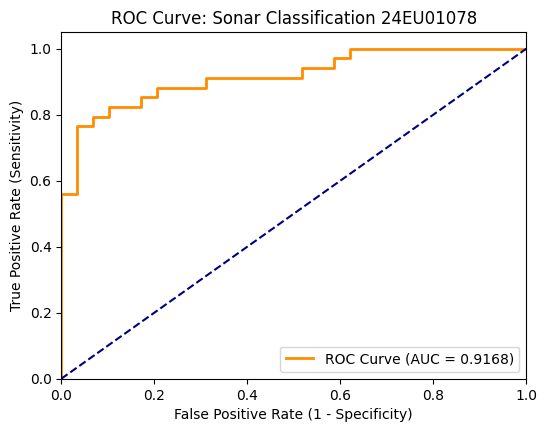

In [292]:
plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve: Sonar Classification 24EU01078")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.show()

Task-3.1

In [293]:
import tensorflow as tf

In [294]:
from tensorflow.keras.models import Sequential

In [295]:
from tensorflow.keras.layers import Dense

In [296]:
def build_ann_model(optimizer_name='adam'):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(8,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer_name,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [297]:
print("Modular ANN model builder function established.")

Modular ANN model builder function established.


Task-3.2

In [298]:
optimizers = ['adam', 'sgd', 'rmsprop']

In [299]:
history_records = {}

In [300]:
print("--- Running Optimizer Search ---")

--- Running Optimizer Search ---


In [318]:
for opt in optimizers:
  print(f"Training network using: {opt}...")
  temp_model = build_ann_model(optimizer_name=opt)
  hist = temp_model.fit(
        X_train_p,
        y_train_p,
        validation_split=0.2,
        epochs=30,
        batch_size=16,
        verbose=0
    )
  history_records[opt] = hist.history['loss']

Training network using: adam...
Training network using: sgd...
Training network using: rmsprop...


In [302]:
print("Tuning loop complete.")

Tuning loop complete.


Task-3.3

In [306]:
import matplotlib.pyplot as plt

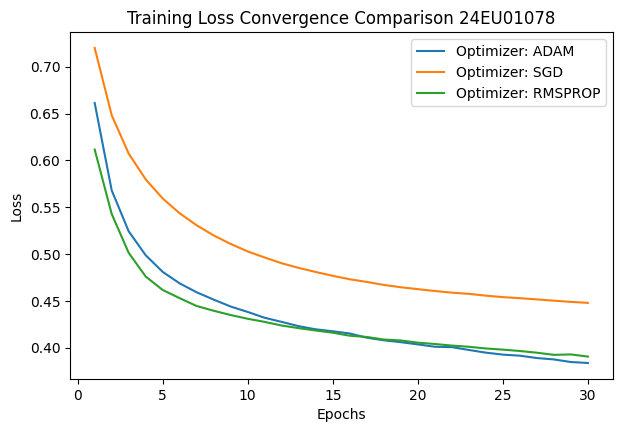

In [305]:
plt.figure(figsize=(7, 4.5))
for opt in optimizers:
  plt.plot(range(1, 31), history_records[opt], label=f"Optimizer: {opt.upper()}")

plt.title("Training Loss Convergence Comparison 24EU01078")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Task-3.4

In [307]:
from tensorflow.keras.callbacks import EarlyStopping

In [308]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [309]:
tuned_model = build_ann_model(optimizer_name='adam')

In [310]:
print("Training model with Early Stopping...")

Training model with Early Stopping...


In [311]:
history_tuned = tuned_model.fit(
    X_train_p,
    y_train_p,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6741 - loss: 0.6549 - val_accuracy: 0.6992 - val_loss: 0.6045
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7149 - loss: 0.5896 - val_accuracy: 0.7480 - val_loss: 0.5404
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7312 - loss: 0.5328 - val_accuracy: 0.7886 - val_loss: 0.4907
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7556 - loss: 0.4924 - val_accuracy: 0.7886 - val_loss: 0.4616
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7821 - loss: 0.4694 - val_accuracy: 0.7886 - val_loss: 0.4443
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7780 - loss: 0.4540 - val_accuracy: 0.7886 - val_loss: 0.4367
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7739 - loss: 0.4456 - val_accuracy: 0.7805 - val_loss: 0.4294
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7882 - loss: 0.4391 - val_accuracy: 0.7967 - 

Task-3.5

In [312]:
from sklearn.metrics import accuracy_score

In [313]:
baseline_accuracy = ann_pima.evaluate(X_test_p, y_test_p, verbose=0)[1]

In [314]:
tuned_accuracy = tuned_model.evaluate(X_test_p, y_test_p, verbose=0)[1]

In [315]:
comparison_df = pd.DataFrame({
    'Model Configuration': ['Baseline ANN (Fixed 50 Epochs)', 'Tuned ANN (with Early Stopping)'],
    'Test Accuracy (%)': [baseline_accuracy * 100, tuned_accuracy * 100],
    'Epochs Trained': [50, len(history_tuned.history['loss'])]
})

In [316]:
print("--- Final Performance Comparison ---")
print(comparison_df.to_string(index=False))

--- Final Performance Comparison ---
            Model Configuration  Test Accuracy (%)  Epochs Trained
 Baseline ANN (Fixed 50 Epochs)          72.727275              50
Tuned ANN (with Early Stopping)          72.077924              57
